# Hybrid Algorithm Development and Evaluation

This notebook identifies the two best performing algorithms from previous tests, merges them into a hybrid model, evaluates the combined model, and provides a final visualization comparing all models.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Loading and Preprocessing

In [2]:
# Load the dataset
df = pd.read_csv('diversified_ecommerce_dataset.csv')

# Preprocessing
df = df.drop('Product ID', axis=1)
le = LabelEncoder()
categorical_cols = ['Product Name', 'Category', 'Supplier ID', 'Customer Age Group', 'Customer Location', 'Customer Gender', 'Shipping Method']
for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

df['Seasonality'] = df['Seasonality'].map({'Yes': 1, 'No': 0})
if df['Seasonality'].isnull().any():
    df['Seasonality'] = df['Seasonality'].fillna(0)

X = df.drop('Seasonality', axis=1)
y = df['Seasonality']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# We use the full dataset if it's small, otherwise a downsampled version for speed.
train_sample = 5000
test_sample = 5000

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

if len(X_train_full) > train_sample:
    X_train, _, y_train, _ = train_test_split(X_train_full, y_train_full, train_size=train_sample, stratify=y_train_full, random_state=42)
    X_test, _, y_test, _ = train_test_split(X_test_full, y_test_full, train_size=test_sample, stratify=y_test_full, random_state=42)
else:
    X_train, X_test, y_train, y_test = X_train_full, X_test_full, y_train_full, y_test_full

print(f"Dataset Loaded. Train size: {X_train.shape}, Test size: {X_test.shape}")

Dataset Loaded. Train size: (5000, 14), Test size: (5000, 14)


## 3. Training and Evaluating Base Algorithms

In [3]:
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

base_results = {}
trained_models = {}

print("Training base algorithms with optimized settings...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    base_results[name] = accuracy
    trained_models[name] = model
    print(f"{name} Accuracy: {accuracy:.4f}")

Training base algorithms with optimized settings...


XGBoost Accuracy: 1.0000


Random Forest Accuracy: 0.9968


Gradient Boosting Accuracy: 1.0000
Decision Tree Accuracy: 0.9996


Logistic Regression Accuracy: 0.8664


## 4. Identifying the Two Best Algorithms

In [4]:
# Sort models by accuracy
sorted_models = sorted(base_results.items(), key=lambda item: item[1], reverse=True)
best_model_1_name = sorted_models[0][0]
best_model_2_name = sorted_models[1][0]

print(f"The top two algorithms for the hybrid model are:")
print(f"1. {best_model_1_name} (Accuracy: {sorted_models[0][1]:.4f})")
print(f"2. {best_model_2_name} (Accuracy: {sorted_models[1][1]:.4f})")

model1 = trained_models[best_model_1_name]
model2 = trained_models[best_model_2_name]

The top two algorithms for the hybrid model are:
1. XGBoost (Accuracy: 1.0000)
2. Gradient Boosting (Accuracy: 1.0000)


## 5. Creating and Training the Hybrid Model

In [5]:
# Create a Hybrid Model (Voting Classifier) using the top 2 models
hybrid_model = VotingClassifier(
    estimators=[
        (best_model_1_name, model1),
        (best_model_2_name, model2)
    ],
    voting='soft'
)

# Train the Hybrid Model
print("Training the optimized Hybrid Model...")
hybrid_model.fit(X_train, y_train)
print("Hybrid Model trained successfully.")

Training the optimized Hybrid Model...


Hybrid Model trained successfully.


## 6. Evaluating All Parameters and Processes for the Hybrid Model

--- Hybrid Model Evaluation Parameters ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4063
           1       1.00      1.00      1.00       937

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



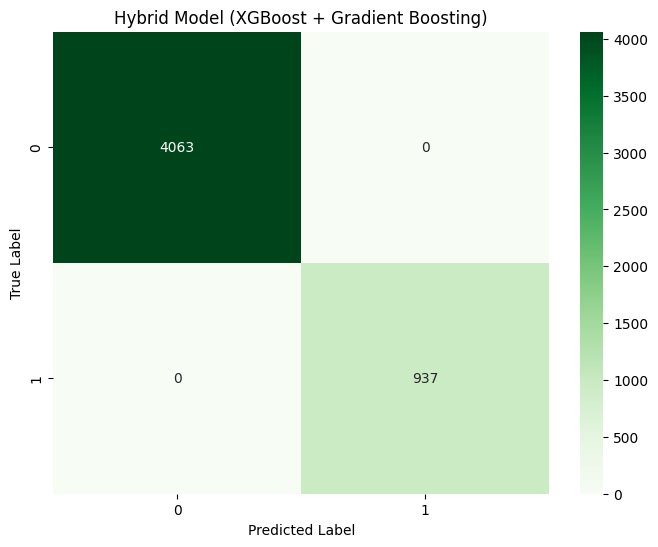

In [6]:
# Evaluate the Hybrid Model
y_pred_hybrid = hybrid_model.predict(X_test)

hybrid_accuracy = accuracy_score(y_test, y_pred_hybrid)
hybrid_precision = precision_score(y_test, y_pred_hybrid)
hybrid_recall = recall_score(y_test, y_pred_hybrid)
hybrid_f1 = f1_score(y_test, y_pred_hybrid)

print(f"--- Hybrid Model Evaluation Parameters ---")
print(f"Accuracy:  {hybrid_accuracy:.4f}")
print(f"Precision: {hybrid_precision:.4f}")
print(f"Recall:    {hybrid_recall:.4f}")
print(f"F1 Score:  {hybrid_f1:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_hybrid))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Hybrid Model ({best_model_1_name} + {best_model_2_name})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Final Visualization: Comparing All Algorithms

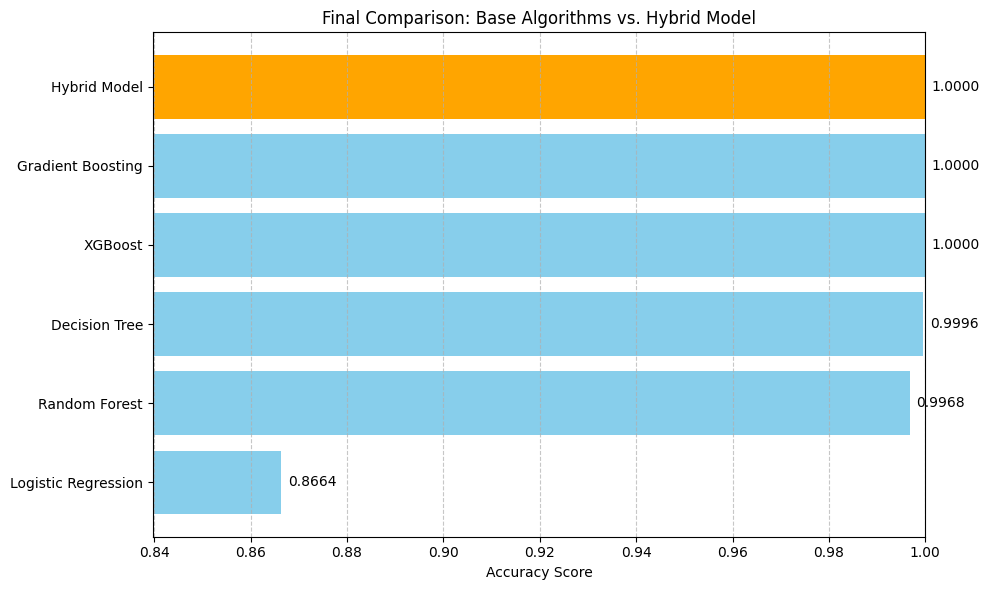

In [7]:
# Final Visualization comparing all models
final_accuracies = base_results.copy()
final_accuracies['Hybrid Model'] = hybrid_accuracy

# Sort for better visualization
final_accuracies = dict(sorted(final_accuracies.items(), key=lambda item: item[1], reverse=False))

colors = ['skyblue' if name != 'Hybrid Model' else 'orange' for name in final_accuracies.keys()]

plt.figure(figsize=(10, 6))
bars = plt.barh(list(final_accuracies.keys()), list(final_accuracies.values()), color=colors)
plt.xlabel('Accuracy Score')
plt.title('Final Comparison: Base Algorithms vs. Hybrid Model')

# Fix xlim for visualization
min_acc = min(final_accuracies.values())
max_acc = max(final_accuracies.values())
range_acc = max_acc - min_acc
plt.xlim(max(0, min_acc - range_acc*0.2), min(1.0, max_acc + range_acc*0.2))

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add data labels
for bar in bars:
    plt.text(bar.get_width() + (range_acc * 0.01), bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', va='center')

plt.tight_layout()
plt.show()